In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklift.models import SoloModel, TwoModels, ClassTransformation
from sklift.metrics import qini_auc_score, uplift_at_k, qini_curve
from sklearn.tree import DecisionTreeRegressor, plot_tree

In [28]:
DATA_PATH = "Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv"

In [29]:
def load_data(path: str = DATA_PATH) -> pd.DataFrame:
    df = pd.read_csv(path)
    print(f"Loaded {df.shape[0]:,} rows, {df.shape[1]} columns")
    print(f"Columns: {list(df.columns)}")
    return df

def basic_overview(df: pd.DataFrame) -> None:
    print("\n--- dtypes ---")
    print(df.dtypes)
    print("\n--- missing values ---")
    print(df.isna().sum())
    print("\n--- segment (treatment) counts ---")
    print(df["segment"].value_counts())


def check_randomization(df: pd.DataFrame) -> None:
    pre_treatment_features = ["recency", "history", "mens", "womens", "newbie"]
    summary = df.groupby("segment")[pre_treatment_features].mean()
    print("\n--- Mean feature values by treatment group (should look similar) ---")
    print(summary)

    fig, axes = plt.subplots(1, len(pre_treatment_features), figsize=(20, 4))
    for ax, feat in zip(axes, pre_treatment_features):
        sns.barplot(data=df, x="segment", y=feat, ax=ax, errorbar=("ci", 95))
        ax.set_title(feat)
        ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

def outcome_rates_by_segment(df: pd.DataFrame) -> None:
    print("\n--- Raw visit / conversion rates by segment (naive view) ---")
    print(df.groupby("segment")[["visit", "conversion", "spend"]].mean())

In [30]:
df = load_data(DATA_PATH)

Loaded 64,000 rows, 12 columns
Columns: ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel', 'segment', 'visit', 'conversion', 'spend']


In [31]:
df.tail()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
63995,10,2) $100 - $200,105.54,1,0,Urban,0,Web,Mens E-Mail,0,0,0.0
63996,5,1) $0 - $100,38.91,0,1,Urban,1,Phone,Mens E-Mail,0,0,0.0
63997,6,1) $0 - $100,29.99,1,0,Urban,1,Phone,Mens E-Mail,0,0,0.0
63998,1,5) $500 - $750,552.94,1,0,Surburban,1,Multichannel,Womens E-Mail,0,0,0.0
63999,1,4) $350 - $500,472.82,0,1,Surburban,0,Web,Mens E-Mail,0,0,0.0


In [32]:
basic_overview(df)


--- dtypes ---
recency              int64
history_segment     object
history            float64
mens                 int64
womens               int64
zip_code            object
newbie               int64
channel             object
segment             object
visit                int64
conversion           int64
spend              float64
dtype: object

--- missing values ---
recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
segment            0
visit              0
conversion         0
spend              0
dtype: int64

--- segment (treatment) counts ---
segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64



--- Mean feature values by treatment group (should look similar) ---
                recency     history      mens    womens    newbie
segment                                                          
Mens E-Mail    5.773642  242.835931  0.550946  0.551415  0.501525
No E-Mail      5.749695  240.882653  0.553224  0.547639  0.501971
Womens E-Mail  5.767850  242.536633  0.548932  0.550101  0.503250


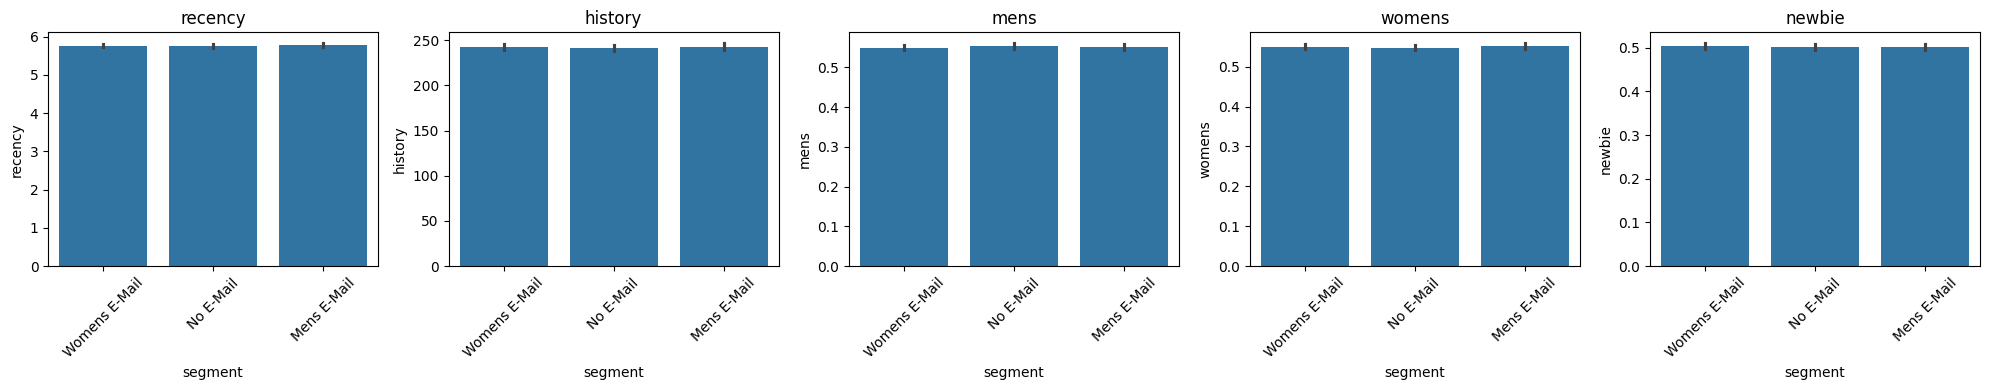

In [33]:
check_randomization(df)

In [34]:
outcome_rates_by_segment(df)


--- Raw visit / conversion rates by segment (naive view) ---
                  visit  conversion     spend
segment                                      
Mens E-Mail    0.182757    0.012531  1.422617
No E-Mail      0.106167    0.005726  0.652789
Womens E-Mail  0.151400    0.008837  1.077202


In [35]:
TARGET = "conversion" 

def prepare_binary_subset(df: pd.DataFrame) -> pd.DataFrame:
    subset = df[df["segment"].isin(["Mens E-Mail", "No E-Mail"])].copy()
    subset["treatment"] = (subset["segment"] == "Mens E-Mail").astype(int)
    subset = pd.get_dummies(subset, columns=["zip_code", "channel"], drop_first=True)
    return subset


def get_feature_columns(df: pd.DataFrame) -> list:
    exclude = ["segment", "treatment", "visit", "conversion", "spend", "history_segment"]
    return [c for c in df.columns if c not in exclude]


def train_naive_classifier(df: pd.DataFrame, feature_cols: list, target=TARGET):
    treated = df[df["treatment"] == 1]
    X, y = treated[feature_cols], treated[target]
    model = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                           eval_metric="logloss", random_state=42)
    model.fit(X, y)
    return model


def score_full_population(df: pd.DataFrame, model, feature_cols: list) -> pd.DataFrame:
    df = df.copy()
    df["naive_score"] = model.predict_proba(df[feature_cols])[:, 1]
    return df


def evaluate_naive_targeting(df: pd.DataFrame, target=TARGET, n_bins=10) -> pd.DataFrame:
    df = df.copy()
    df["decile"] = pd.qcut(df["naive_score"], n_bins, labels=False, duplicates="drop")
    df["decile"] = df["decile"].max() - df["decile"] + 1  # decile 1 = highest score

    results = []
    for d in sorted(df["decile"].unique()):
        bucket = df[df["decile"] == d]
        treated_rate = bucket.loc[bucket["treatment"] == 1, target].mean()
        control_rate = bucket.loc[bucket["treatment"] == 0, target].mean()
        results.append({
            "decile": d,
            "n_treated": (bucket["treatment"] == 1).sum(),
            "n_control": (bucket["treatment"] == 0).sum(),
            "avg_naive_score": bucket["naive_score"].mean(),
            "treated_rate": treated_rate,
            "control_rate": control_rate,
            "actual_uplift": treated_rate - control_rate,
        })
    return pd.DataFrame(results)


def plot_naive_vs_actual(results_df: pd.DataFrame, target=TARGET):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    ax[0].bar(results_df["decile"], results_df["avg_naive_score"], color="steelblue")
    ax[0].set_title("Naive model's predicted probability by decile")
    ax[0].set_xlabel("Decile (1 = highest predicted)")
    ax[0].set_ylabel(f"Predicted P({target})")

    ax[1].bar(results_df["decile"], results_df["actual_uplift"], color="darkorange")
    ax[1].set_title("ACTUAL uplift by decile (ground truth)")
    ax[1].set_xlabel("Decile (1 = highest predicted)")
    ax[1].set_ylabel("Treated rate - Control rate")
    ax[1].axhline(0, color="black", linewidth=0.8)
    plt.tight_layout()
    plt.show()

In [36]:
sub = prepare_binary_subset(df)       
feats = get_feature_columns(sub)
print(feats)

['recency', 'history', 'mens', 'womens', 'newbie', 'zip_code_Surburban', 'zip_code_Urban', 'channel_Phone', 'channel_Web']


In [37]:
model = train_naive_classifier(sub, feats)

In [38]:
scored = score_full_population(sub, model, feats)

In [39]:
results = evaluate_naive_targeting(scored)
results

,decile,n_treated,n_control,avg_naive_score,treated_rate,control_rate,actual_uplift
0,1,2109,2153,0.035981,0.067330,0.006038,0.061292
1,2,2154,2099,0.020818,0.020891,0.012863,0.008028
2,3,2178,2088,0.015868,0.015152,0.006226,0.008925
3,4,2085,2179,0.012946,0.005755,0.008720,-0.002964
4,5,2203,2054,0.010674,0.007263,0.004382,0.002881
5,6,2098,2143,0.008707,0.003337,0.004666,-0.001330
6,7,2120,2166,0.007167,0.004245,0.003693,0.000552
7,8,2114,2147,0.005800,0.001419,0.003726,-0.002307
8,9,2116,2144,0.004467,0.000000,0.003265,-0.003265
9,10,2130,2133,0.002781,0.000000,0.003751,-0.003751


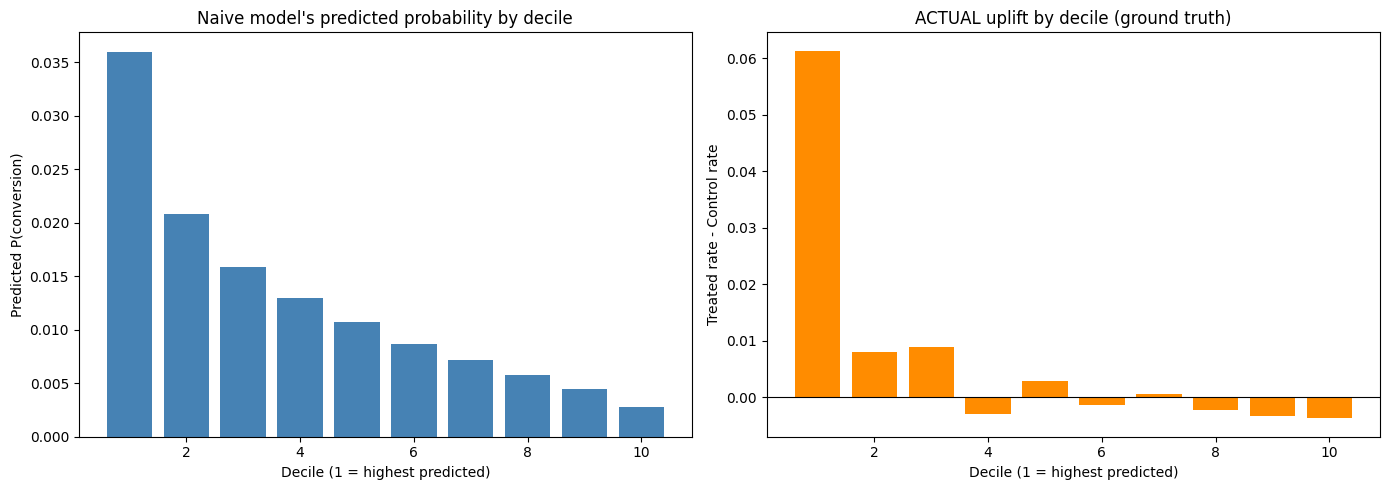

In [14]:
plot_naive_vs_actual(results)

In [15]:
def prepare_binary_subset(df):
    subset = df[df["segment"].isin(["Mens E-Mail", "No E-Mail"])].copy()
    subset["treatment"] = (subset["segment"] == "Mens E-Mail").astype(int)
    subset = pd.get_dummies(subset, columns=["zip_code", "channel"], drop_first=True)
    return subset


def get_feature_columns(df):
    exclude = ["segment", "treatment", "visit", "conversion", "spend", "history_segment"]
    return [c for c in df.columns if c not in exclude]


def split_data(df, feature_cols, target=TARGET, test_size=0.3, random_state=42):
    X, y, trt = df[feature_cols], df[target], df["treatment"]
    return train_test_split(X, y, trt, test_size=test_size, random_state=random_state, stratify=trt)


def make_base_estimator(random_state=42):
    return XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                          eval_metric="logloss", random_state=random_state)


def train_s_learner(X_train, y_train, trt_train):
    model = SoloModel(make_base_estimator())
    model.fit(X_train, y_train, trt_train)
    return model


def train_t_learner(X_train, y_train, trt_train):
    model = TwoModels(estimator_trmnt=make_base_estimator(42),
                       estimator_ctrl=make_base_estimator(43), method="vanilla")
    model.fit(X_train, y_train, trt_train)
    return model


def train_class_transformation(X_train, y_train, trt_train):
    model = ClassTransformation(make_base_estimator())
    model.fit(X_train, y_train, trt_train)
    return model


def evaluate_all_models(models: dict, X_test, y_test, trt_test):
    rows, predictions = [], {}
    for name, model in models.items():
        uplift_pred = model.predict(X_test)
        predictions[name] = uplift_pred
        rows.append({
            "model": name,
            "qini_auc": qini_auc_score(y_test, uplift_pred, trt_test),
            "uplift_at_top_30pct": uplift_at_k(y_test, uplift_pred, trt_test, strategy="overall", k=0.3),
        })
    results = pd.DataFrame(rows).sort_values("qini_auc", ascending=False).reset_index(drop=True)
    return results, predictions


def plot_qini_curves(predictions: dict, y_test, trt_test):
    n = len(y_test)
    plt.figure(figsize=(8, 6))
    last_point = None
    for name, uplift_pred in predictions.items():
        order, qini_values = qini_curve(y_test.values, uplift_pred, trt_test.values)
        x_pct = np.array(order) / n * 100
        plt.plot(x_pct, qini_values, label=name, linewidth=2)
        last_point = qini_values[-1]

    plt.plot([0, 100], [0, last_point], linestyle="--", color="gray", label="Random targeting")
    plt.xlabel("% of population targeted (sorted by predicted uplift)")
    plt.ylabel("Cumulative incremental responders")
    plt.title("Qini Curve Comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [16]:
X_train, X_test, y_train, y_test, trt_train, trt_test = split_data(sub, feats)

In [17]:
s_model = train_s_learner(X_train, y_train, trt_train)
t_model = train_t_learner(X_train, y_train, trt_train)
ct_model = train_class_transformation(X_train, y_train, trt_train)

In [18]:
models = {"S-Learner": s_model, "T-Learner": t_model, "Class Transformation": ct_model}
results, predictions = evaluate_all_models(models, X_test, y_test, trt_test)
results

,model,qini_auc,uplift_at_top_30pct
0,T-Learner,0.067308,0.007845
1,Class Transformation,0.036633,0.006898
2,S-Learner,0.032883,0.009373


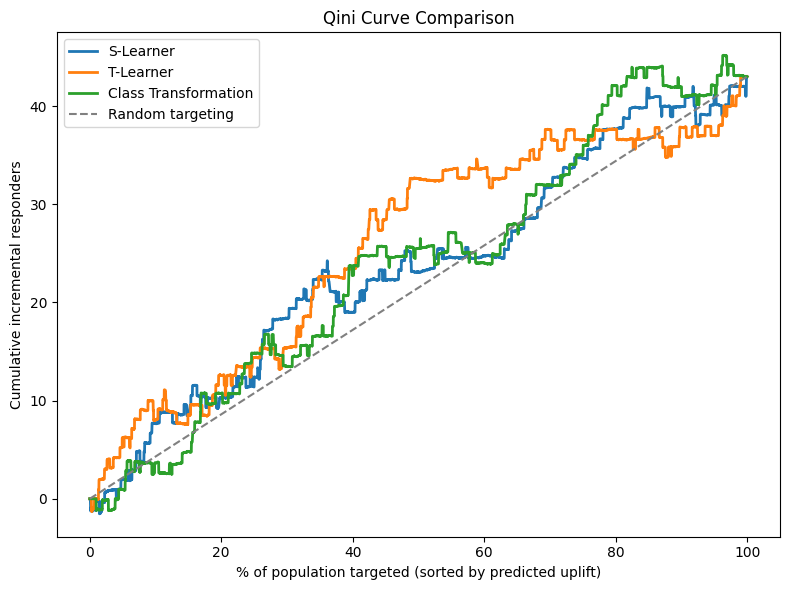

In [19]:
plot_qini_curves(predictions, y_test, trt_test)

In [21]:

def explain_uplift_with_surrogate(X_test, uplift_pred, max_depth=3):
    surrogate = DecisionTreeRegressor(max_depth=max_depth, random_state=42)
    surrogate.fit(X_test, uplift_pred)

    importances = pd.Series(surrogate.feature_importances_, index=X_test.columns)
    importances = importances[importances > 0].sort_values(ascending=False)
    print("Features that most explain WHO the model ranks as a Persuadable:")
    print(importances)

    plt.figure(figsize=(16, 8))
    plot_tree(surrogate, feature_names=list(X_test.columns), filled=True,
              rounded=True, fontsize=9)
    plt.title("Surrogate tree: what kind of customer is a Persuadable?")
    plt.tight_layout()
    plt.show()

    return surrogate, importances



def business_value_by_targeting_level(uplift_pred, trt_test, spend_test,
                                       k_values=(0.1, 0.2, 0.3, 0.5, 1.0),
                                       cost_per_email=1.0):
    n = len(uplift_pred)
    order = np.argsort(-uplift_pred)  

    rows = []
    for k in k_values:
        top_n = max(1, int(n * k))
        idx = order[:top_n]
        bucket_trt = trt_test.values[idx] if hasattr(trt_test, "values") else trt_test[idx]
        bucket_spend = spend_test.values[idx] if hasattr(spend_test, "values") else spend_test[idx]

        treated_avg_spend = bucket_spend[bucket_trt == 1].mean()
        control_avg_spend = bucket_spend[bucket_trt == 0].mean()
        incremental_spend_per_customer = treated_avg_spend - control_avg_spend

        projected_incremental_revenue = incremental_spend_per_customer * top_n
        campaign_cost = cost_per_email * top_n
        net_value = projected_incremental_revenue - campaign_cost
        roi = (projected_incremental_revenue / campaign_cost) if campaign_cost > 0 else np.nan

        rows.append({
            "targeted_pct": f"{int(k * 100)}%",
            "n_emailed": top_n,
            "incremental_$_per_customer": round(incremental_spend_per_customer, 3),
            "projected_incremental_revenue": round(projected_incremental_revenue, 2),
            "campaign_cost": round(campaign_cost, 2),
            "net_value": round(net_value, 2),
            "roi": round(roi, 2) if not np.isnan(roi) else None,
        })

    return pd.DataFrame(rows)


def plot_business_value(biz_df):
    fig, ax1 = plt.subplots(figsize=(9, 5))
    x = biz_df["targeted_pct"]

    ax1.bar(x, biz_df["net_value"], color="seagreen", alpha=0.7, label="Net value ($)")
    ax1.axhline(0, color="black", linewidth=0.8)
    ax1.set_xlabel("% of customers targeted (sorted by predicted uplift)")
    ax1.set_ylabel("Net value ($)", color="seagreen")

    ax2 = ax1.twinx()
    ax2.plot(x, biz_df["roi"], color="darkorange", marker="o", linewidth=2, label="ROI")
    ax2.set_ylabel("ROI (revenue / cost)", color="darkorange")
    ax2.axhline(1, color="darkorange", linestyle="--", linewidth=0.8)

    plt.title("Net Value & ROI by Targeting Level")
    fig.tight_layout()
    plt.show()

In [22]:
predictions["T-Learner"]

array([0.18777658, 0.00353902, 0.01299943, ..., 0.00560704, 0.01324528,
       0.00505481], shape=(12784,), dtype=float32)

In [23]:
uplift_pred = predictions["T-Learner"]
spend_test = sub.loc[X_test.index, "spend"]

Features that most explain WHO the model ranks as a Persuadable:
history    0.578239
womens     0.280460
recency    0.059104
mens       0.045586
newbie     0.036611
dtype: float64


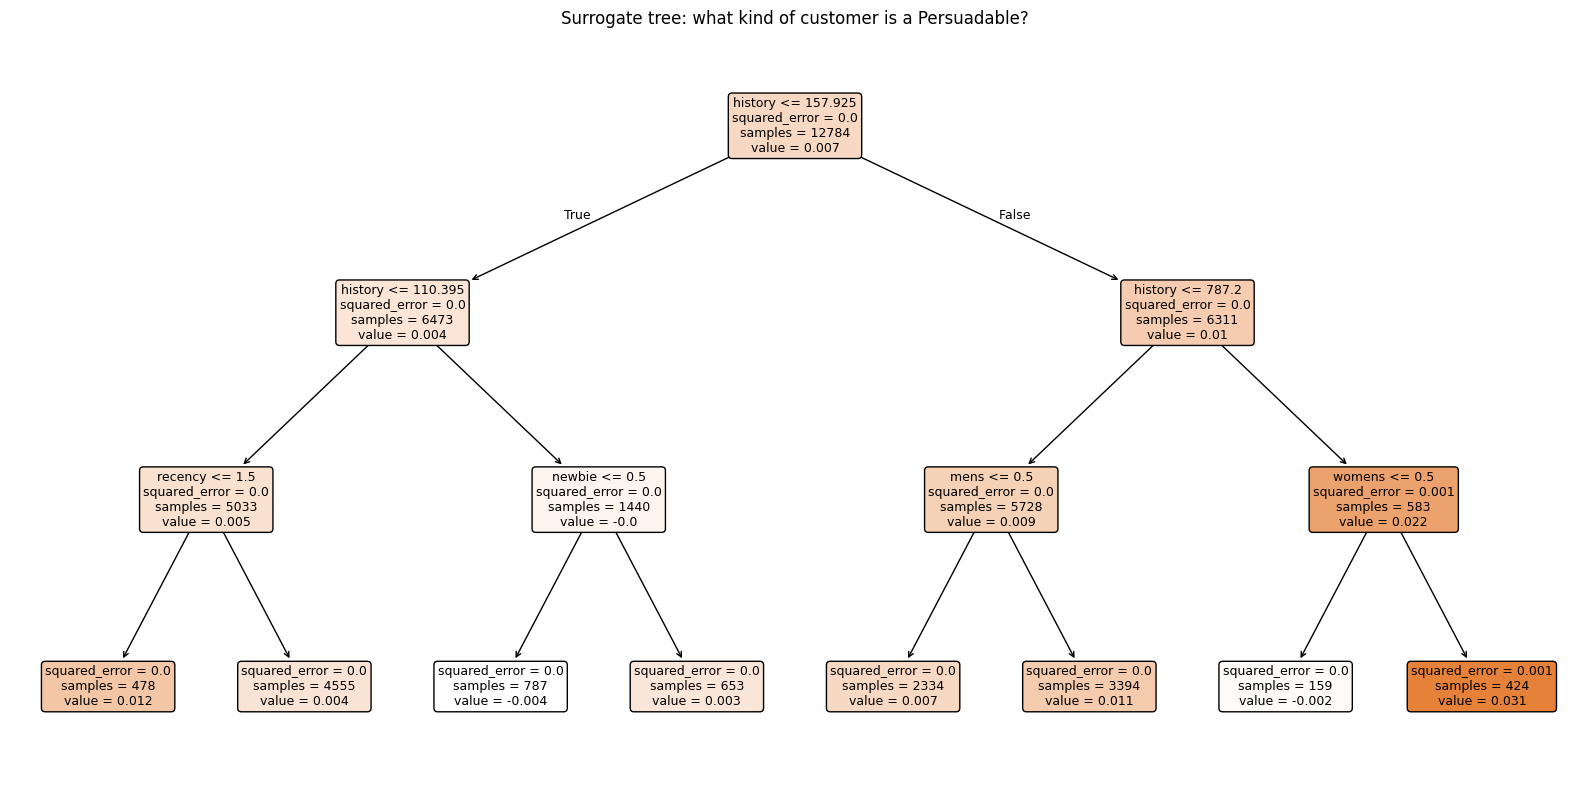

In [24]:
surrogate, importances = explain_uplift_with_surrogate(X_test, uplift_pred)

In [25]:
biz = business_value_by_targeting_level(uplift_pred, trt_test, spend_test)
biz

,targeted_pct,n_emailed,incremental_$_per_customer,projected_incremental_revenue,campaign_cost,net_value,roi
0,10%,1278,2.032,2596.81,1278.0,1318.81,2.03
1,20%,2556,1.633,4173.71,2556.0,1617.71,1.63
2,30%,3835,1.199,4596.81,3835.0,761.81,1.20
3,50%,6392,1.401,8953.88,6392.0,2561.88,1.40
4,100%,12784,1.026,13122.54,12784.0,338.54,1.03


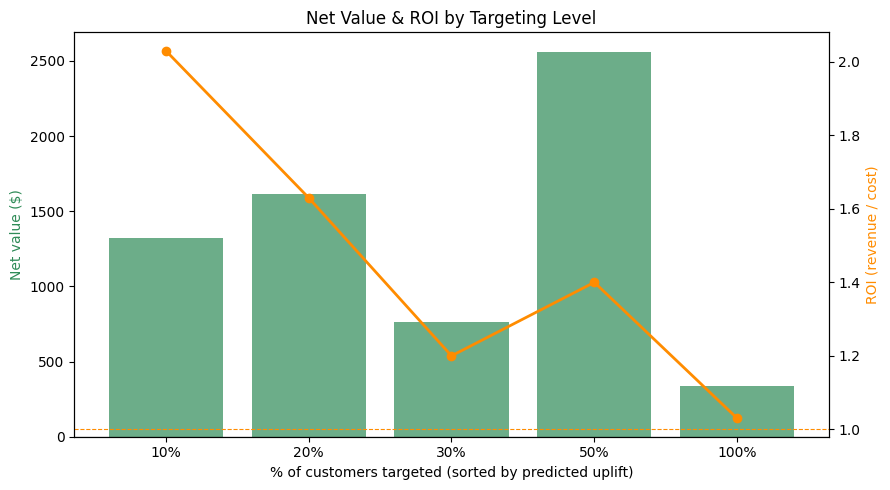

In [26]:
plot_business_value(biz)